## Classification Exploration 1: K-Nearest Neighbor (KNN)

# [Classification: k-Nearest Neighbors](https://en.wikipedia.org/wiki/K-nearest_neighbors_algorithm)

The IBM HR Analytics Employee Attrition dataset contains fictional data created by IBM data scientists. 
It includes 1,470 employee records with 35 features covering demographics, job roles, satisfaction levels, 
and compensation. The target variable is **Attrition** — whether an employee left the company (Yes/No).

In [43]:
import pandas as pd

df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [8]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [9]:
df.shape

(1470, 35)

## Exploratory Data Analysis

In [11]:
df.info(verbose=True)
# Shows an overview of the dataset, including data types and any missing values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [12]:
df.isna().sum()
# Check for missing values in each column

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [13]:
df.describe(include="all")
# Provides a statistical summary of the dataset.

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470,1470,1470.000000,1470,1470.000000,1470.000000,1470,1470.0,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
unique,NaN,2,3,NaN,3,NaN,NaN,6,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,No,Travel_Rarely,NaN,Research & Development,NaN,NaN,Life Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1233,1043,NaN,961,NaN,NaN,606,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,36.923810,NaN,NaN,802.485714,NaN,9.192517,2.912925,NaN,1.0,1024.865306,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,NaN,NaN,403.509100,NaN,8.106864,1.024165,NaN,0.0,602.024335,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,NaN,NaN,102.000000,NaN,1.000000,1.000000,NaN,1.0,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,NaN,NaN,465.000000,NaN,2.000000,2.000000,NaN,1.0,491.250000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,NaN,NaN,802.000000,NaN,7.000000,3.000000,NaN,1.0,1020.500000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,NaN,NaN,1157.000000,NaN,14.000000,4.000000,NaN,1.0,1555.750000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000


<Axes: >

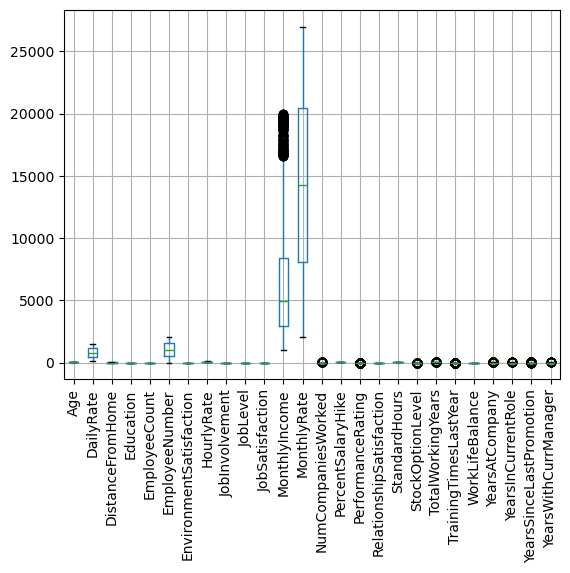

In [14]:
%matplotlib inline
df.boxplot(rot=90)

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'DailyRate'}>,
        <Axes: title={'center': 'DistanceFromHome'}>,
        <Axes: title={'center': 'Education'}>,
        <Axes: title={'center': 'EmployeeCount'}>],
       [<Axes: title={'center': 'EmployeeNumber'}>,
        <Axes: title={'center': 'EnvironmentSatisfaction'}>,
        <Axes: title={'center': 'HourlyRate'}>,
        <Axes: title={'center': 'JobInvolvement'}>,
        <Axes: title={'center': 'JobLevel'}>],
       [<Axes: title={'center': 'JobSatisfaction'}>,
        <Axes: title={'center': 'MonthlyIncome'}>,
        <Axes: title={'center': 'MonthlyRate'}>,
        <Axes: title={'center': 'NumCompaniesWorked'}>,
        <Axes: title={'center': 'PercentSalaryHike'}>],
       [<Axes: title={'center': 'PerformanceRating'}>,
        <Axes: title={'center': 'RelationshipSatisfaction'}>,
        <Axes: title={'center': 'StandardHours'}>,
        <Axes: title={'center': 'StockOptionLevel'}>,
        <Axe

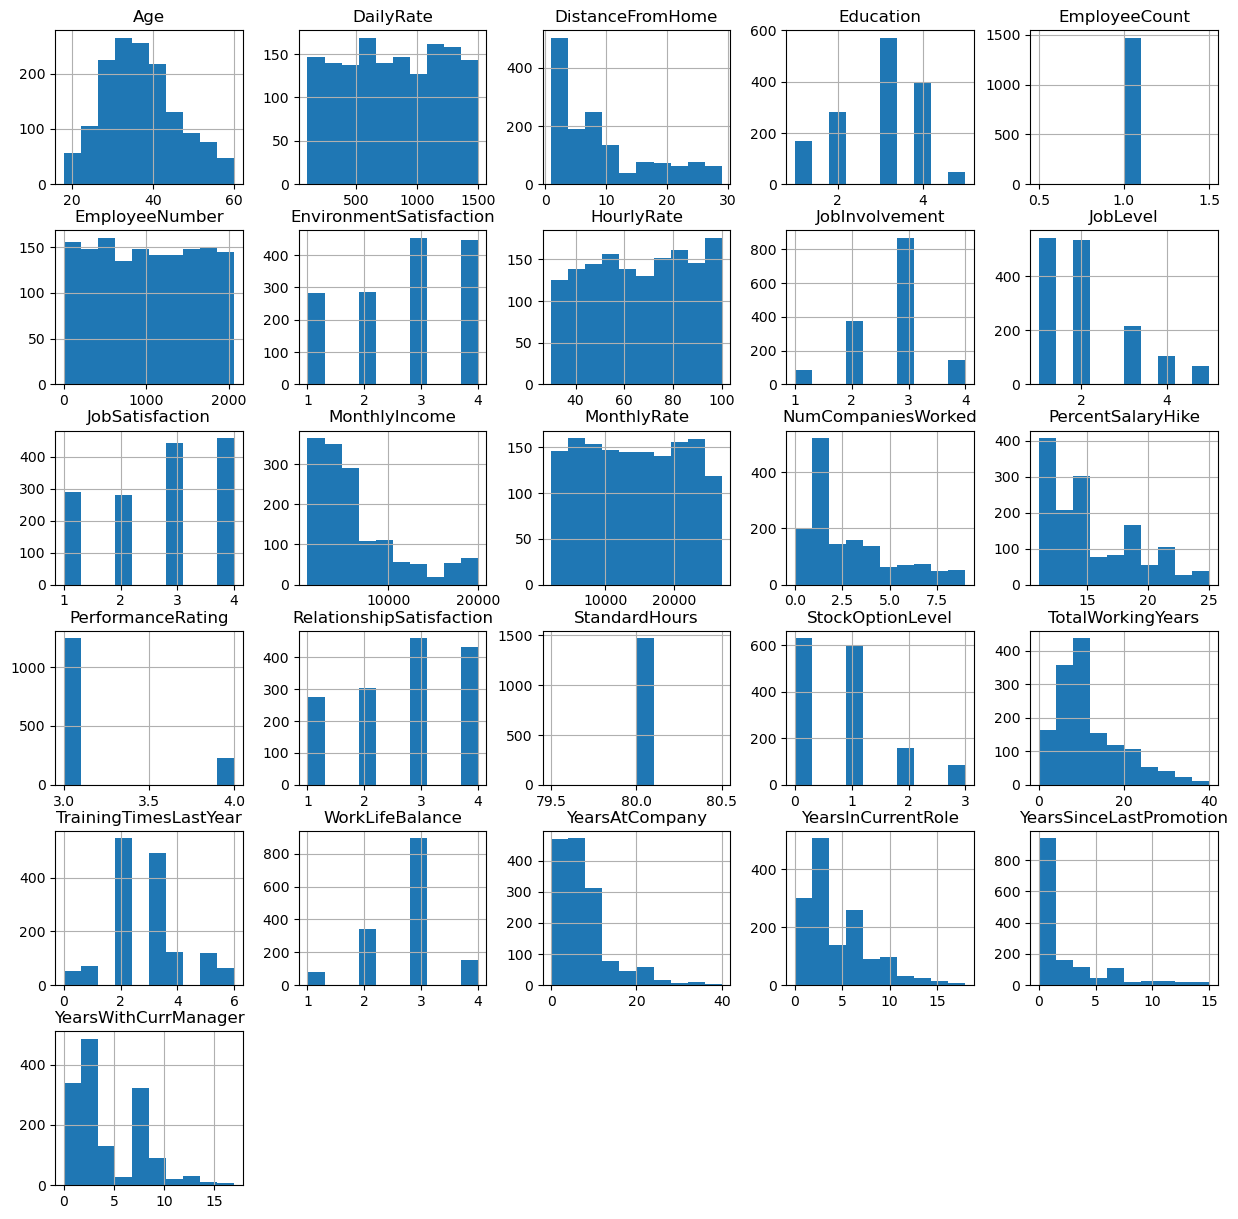

In [15]:
df.hist(figsize=(15,15))

Attrition
No     1233
Yes     237
dtype: int64


<Axes: title={'center': 'Distribution of Attrition'}, xlabel='Attrition'>

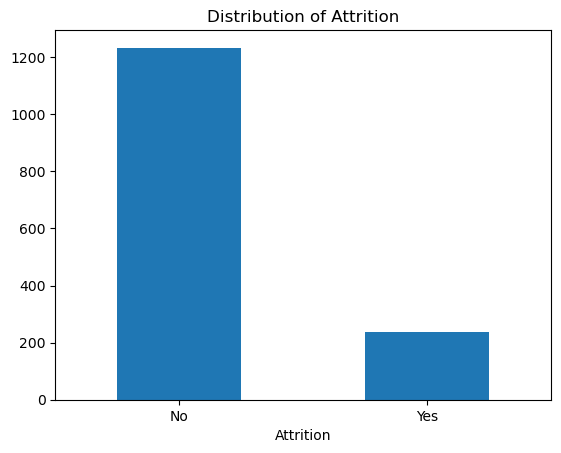

In [16]:
# Print class frequency of the target variable
target_dist = df.groupby('Attrition').size()
print(target_dist)

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

target_dist.plot.bar(rot=0, title='Distribution of Attrition')

## Data Preparation

In [17]:
# Drop constant columns — they add no information
df = df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'StandardHours', 'Over18'])

In [18]:
# Encode categorical columns using pd.get_dummies
df = pd.get_dummies(df, columns=['BusinessTravel', 'Department', 'EducationField',
                                  'Gender', 'JobRole', 'MaritalStatus', 'OverTime'],
                    drop_first=True)

In [19]:
# Encode target variable: Yes → 1, No → 0
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

### Separate Train/Test sets

In [20]:
# Separate X and y (explanatory variables and target variable)
X = df.drop(columns=['Attrition'])
y = df['Attrition']

X.head()
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64

In [21]:
from sklearn.model_selection import train_test_split

# SPLIT DATA INTO TRAIN AND TEST SET
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                     test_size=0.30,        # 70% train, 30% test
                                                     stratify=y,            # preserve class imbalance
                                                     random_state=123)      # fix seed for replicability

print(X_train.shape, X_test.shape)

(1029, 44) (441, 44)


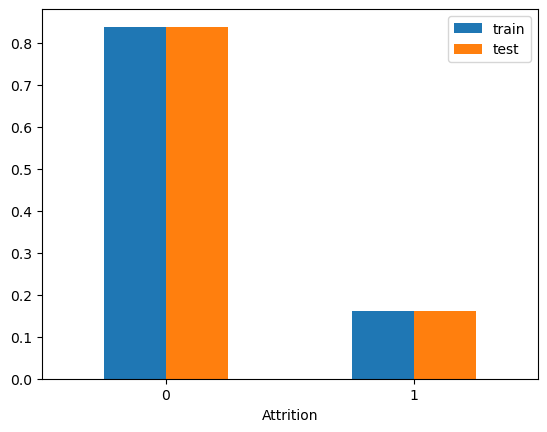

In [22]:
y_train_dist = y_train.groupby(y_train.iloc[:]).size() / y_train.size
y_test_dist = y_test.groupby(y_test.iloc[:]).size() / y_test.size

train_test_dist = pd.DataFrame({'train': y_train_dist, 'test': y_test_dist})
ax = train_test_dist.plot.bar(rot=0)
plt.show()

# A first model: K-Nearest Neighbor

The K-Nearest Neighbor classification model simply assigns to a new observation the most frequent class among its k nearest neighbors in the feature space.

In [23]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# Create KNN Classifier
knn40 = KNeighborsClassifier(n_neighbors=40)

# Train the model using the training sets
knn40.fit(X_train, y_train)

# Predict the response for the test dataset
y_pred = knn40.predict(X_test)

In [24]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

### Classification Quality

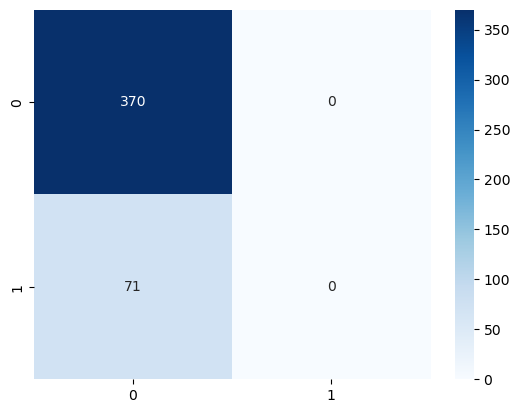

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues")
plt.show()

# rows: true values
# columns: predicted

In [26]:
# EVALUATE OUR PREDICTION
from sklearn import metrics

print('***RESULTS ON TEST SET***')
print("F1_score: ", metrics.f1_score(y_test, y_pred))
print("precision: ", metrics.precision_score(y_test, y_pred))
print("recall: ", metrics.recall_score(y_test, y_pred))
print("accuracy: ", metrics.accuracy_score(y_test, y_pred))

***RESULTS ON TEST SET***
F1_score:  0.0
precision:  0.0
recall:  0.0
accuracy:  0.8390022675736961


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Searching the best parameters

#### DEFINE YOUR GRIDSEARCH

GS performs an exhaustive search over specified parameter values for an estimator.
GS uses cross-validation to evaluate each combination of parameters.

In [27]:
from sklearn.model_selection import GridSearchCV

# Create KNN Classifier
classifier = KNeighborsClassifier()
parameters = {'n_neighbors': np.arange(1, 40, 2)}

gs = GridSearchCV(classifier, parameters, scoring='f1', cv=5)

In [28]:
# TRAIN YOUR CLASSIFIER
gs = gs.fit(X_train, y_train)

In [29]:
# summarize the results of your GRIDSEARCH
print("Best score: %f using %s" % (gs.best_score_, gs.best_params_))

means = gs.cv_results_['mean_test_score']
stds = gs.cv_results_['std_test_score']
params = gs.cv_results_['params']

for mean, stdev, param in zip(means, stds, params):
    print("Mean %f Std (%f) with: %r" % (mean, stdev, param))

Best score: 0.265625 using {'n_neighbors': np.int64(1)}
Mean 0.265625 Std (0.069305) with: {'n_neighbors': np.int64(1)}
Mean 0.180312 Std (0.057394) with: {'n_neighbors': np.int64(3)}
Mean 0.103758 Std (0.033355) with: {'n_neighbors': np.int64(5)}
Mean 0.081141 Std (0.038121) with: {'n_neighbors': np.int64(7)}
Mean 0.073135 Std (0.020248) with: {'n_neighbors': np.int64(9)}
Mean 0.052418 Std (0.028878) with: {'n_neighbors': np.int64(11)}
Mean 0.043943 Std (0.022429) with: {'n_neighbors': np.int64(13)}
Mean 0.021521 Std (0.026548) with: {'n_neighbors': np.int64(15)}
Mean 0.000000 Std (0.000000) with: {'n_neighbors': np.int64(17)}
Mean 0.000000 Std (0.000000) with: {'n_neighbors': np.int64(19)}
Mean 0.000000 Std (0.000000) with: {'n_neighbors': np.int64(21)}
Mean 0.000000 Std (0.000000) with: {'n_neighbors': np.int64(23)}
Mean 0.000000 Std (0.000000) with: {'n_neighbors': np.int64(25)}
Mean 0.000000 Std (0.000000) with: {'n_neighbors': np.int64(27)}
Mean 0.000000 Std (0.000000) with: {'n_

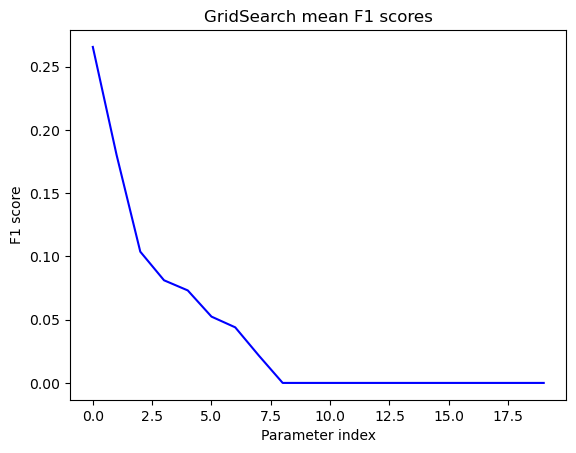

0.26562453394040825


In [30]:
import matplotlib.pyplot as plt

plt.plot(means, color='blue', alpha=1.00)
plt.xlabel('Parameter index')
plt.ylabel('F1 score')
plt.title('GridSearch mean F1 scores')
plt.show()

print(gs.best_score_)

In [31]:
# TEST ON YOUR TEST SET
best_model = gs.best_estimator_

y_pred_train = best_model.predict(X_train)
y_pred = best_model.predict(X_test)

In [32]:
# EVALUATE YOUR PREDICTION IN THE TRAINING SET
print('***RESULTS ON TRAIN SET***')
print("precision: ", metrics.precision_score(y_train, y_pred_train))
print("recall: ", metrics.recall_score(y_train, y_pred_train))
print("f1_score: ", metrics.f1_score(y_train, y_pred_train))
print("accuracy: ", metrics.accuracy_score(y_train, y_pred_train))

***RESULTS ON TRAIN SET***
precision:  1.0
recall:  1.0
f1_score:  1.0
accuracy:  1.0


In [33]:
# EVALUATE YOUR PREDICTION IN THE TEST SET
print('***RESULTS ON TEST SET***')
print("precision: ", metrics.precision_score(y_test, y_pred))
print("recall: ", metrics.recall_score(y_test, y_pred))
print("f1_score: ", metrics.f1_score(y_test, y_pred))
print("accuracy: ", metrics.accuracy_score(y_test, y_pred))

***RESULTS ON TEST SET***
precision:  0.24285714285714285
recall:  0.23943661971830985
f1_score:  0.24113475177304963
accuracy:  0.7573696145124716


In [34]:
# PRINT SOME FURTHER METRICS
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.86      0.86       370
           1       0.24      0.24      0.24        71

    accuracy                           0.76       441
   macro avg       0.55      0.55      0.55       441
weighted avg       0.76      0.76      0.76       441



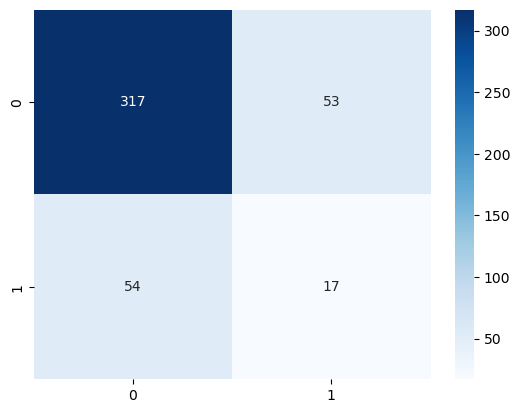

In [35]:
# Plot confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues")
plt.show()

## Scaling

In [36]:
from sklearn.preprocessing import StandardScaler

# Scale the data
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [37]:
# DEFINE PARAMETERS GRID
classifier = KNeighborsClassifier()
parameters = {'n_neighbors': np.arange(1, 40, 2)}

gs = GridSearchCV(classifier, parameters, scoring='f1', cv=5)
gs = gs.fit(scaled_X_train, y_train)

print("Best score: %f using %s" % (gs.best_score_, gs.best_params_))

Best score: 0.262712 using {'n_neighbors': np.int64(1)}


In [38]:
best_model = gs.best_estimator_

y_pred_train = best_model.predict(scaled_X_train)
y_pred = best_model.predict(scaled_X_test)

print('***RESULTS ON TRAIN SET***')
print("precision: ", metrics.precision_score(y_train, y_pred_train))
print("recall: ", metrics.recall_score(y_train, y_pred_train))
print("f1_score: ", metrics.f1_score(y_train, y_pred_train))
print("accuracy: ", metrics.accuracy_score(y_train, y_pred_train))

print('\n***RESULTS ON TEST SET***')
print("precision: ", metrics.precision_score(y_test, y_pred))
print("recall: ", metrics.recall_score(y_test, y_pred))
print("f1_score: ", metrics.f1_score(y_test, y_pred))
print("accuracy: ", metrics.accuracy_score(y_test, y_pred))

***RESULTS ON TRAIN SET***
precision:  1.0
recall:  1.0
f1_score:  1.0
accuracy:  1.0

***RESULTS ON TEST SET***
precision:  0.25925925925925924
recall:  0.19718309859154928
f1_score:  0.224
accuracy:  0.780045351473923


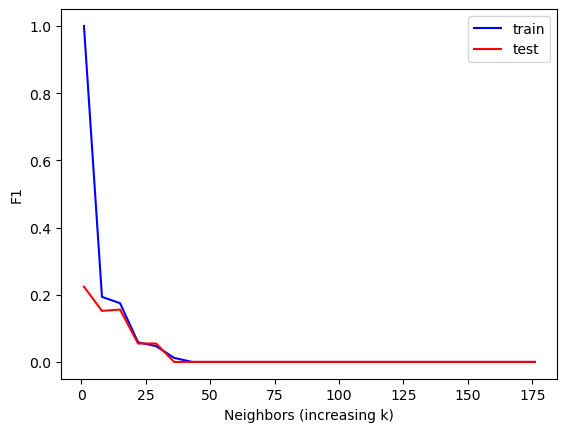

In [39]:
score_train = []
score_test = []

neighbors = range(1, 180, 7)

for i in neighbors:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(scaled_X_train, y_train)
    y_pred_train = knn.predict(scaled_X_train)
    y_pred_test = knn.predict(scaled_X_test)
    score_train.append(metrics.f1_score(y_train, y_pred_train))
    score_test.append(metrics.f1_score(y_test, y_pred_test))

plt.plot(neighbors, score_train, color='blue', alpha=1.00, label='train')
plt.plot(neighbors, score_test, color='red', alpha=1.00, label='test')
plt.xlabel('Neighbors (increasing k)')
plt.ylabel('F1')
plt.legend()
plt.show()

In [40]:
# Find the k where train and test scores are closest
neighbors_list = list(neighbors)
diff = [abs(score_train[i] - score_test[i]) for i in range(len(neighbors_list))]
best_k = neighbors_list[diff.index(min(diff))]
best_test_f1 = score_test[diff.index(min(diff))]

print(f"Best k (smallest train/test gap): {best_k}")
print(f"Test F1 at that k: {best_test_f1:.4f}")

Best k (smallest train/test gap): 43
Test F1 at that k: 0.0000


In [41]:
best_k = neighbors_list[score_test.index(max(score_test))]
best_test_f1 = max(score_test)

print(f"Best k (highest test F1): {best_k}")
print(f"Test F1 at that k: {best_test_f1:.4f}")

Best k (highest test F1): 1
Test F1 at that k: 0.2240


## ROC Curve

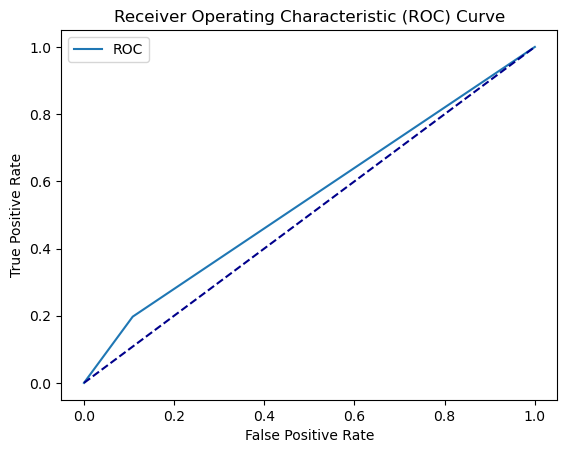

AUC: 0.54


In [42]:
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(scaled_X_train, y_train)
y_pred = model.predict(scaled_X_test)

y_probs = model.predict_proba(scaled_X_test)
# predict_proba gives the probabilities for the target (0 and 1)
# y_probs[:, 1] extracts the probabilities of the positive class (Attrition = Yes)

fpr, tpr, thresholds = metrics.roc_curve(y_test, y_probs[:, 1])

plt.plot(fpr, tpr, label='ROC')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

auc = metrics.roc_auc_score(y_test, y_probs[:, 1])
print('AUC: %.2f' % auc)